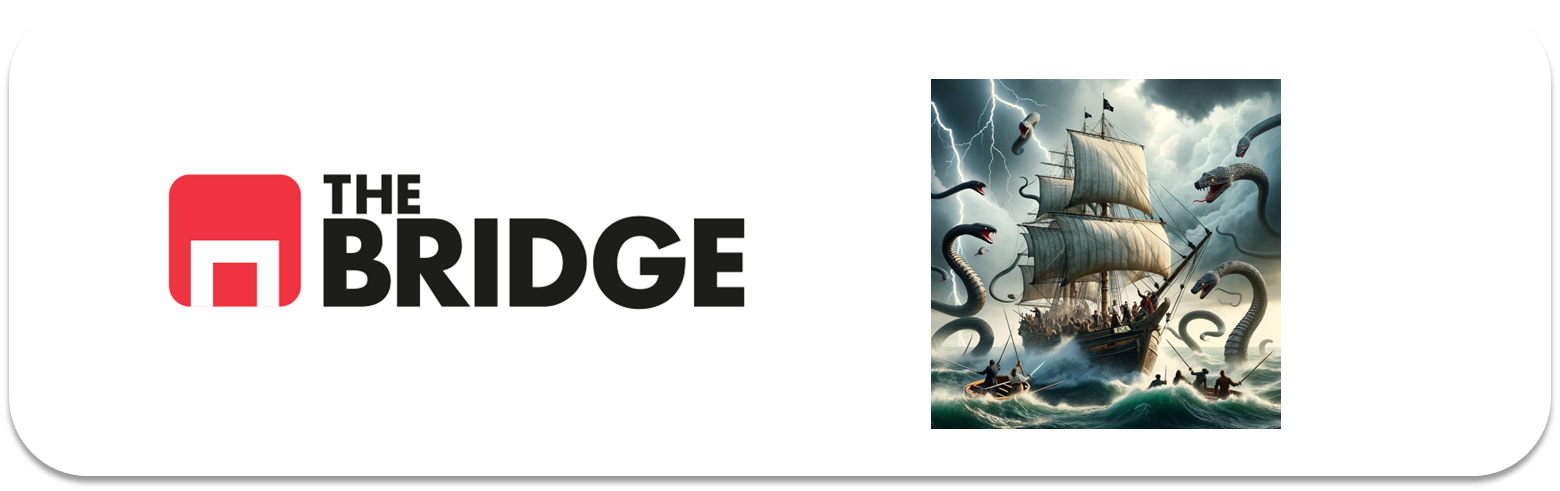

## PRACTICA OBLIGATORIA: **No Supervisado: PCA**

* La práctica obligatoria de esta unidad consiste en aplicar PCA a un dataset de imágenes con diferentes objetivos y compromisos. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### El problema de negocio

El Caesar Palace de las Vegas está planificando la instalación de mil quininetas microcámaras en los accesos a sus instalaciones para las próximas sesiones del "Poker World Championship". Estas microcámaras tienen la peculiaridad de que son capaces de tomar fotos encuadradas de las caras y la desventaja de que no tienen un gran ancho de banda de comunicación. (Las había de más ancho y de mayor precio...). NOTA: El ancho de banda limita el tamaño de las imágenes que pueden enviar las microcámaras).

El objetivo de las microcámaras es el de detectar personas "non-gratas" en tiempo real, pudiendo posprocesar las imágenes para poder detectar si han accedido a las instalaciones personas que estuvieran perseguidas por la ley, en los bancos de datos de los casinos identificadas como "peligrosas" (no se sabe si para el resto de personas o para los beneficios de los casinos) y en las listas de no admisión de jugadores adictos. Por eso no necesitan procesar los datos en tiempo real, pero sí enviarlos a un repositorio central. 

¿Cuál es su problema? O bien comprimen las imágenes y las procesan comprimidas en cada microcámara (pueden comprimir muy rápido pero no tienen cpu para procesarlas sin comprimir) o bien las comprimen y las mandan a un servidor central muy rápido (por eso ti) donde se descomprimirían y se analizarían. Analizar quiere decir en este contexto, pasarles un modelo de clasificación que determine si la persona de la imagen es una de las listas prohibidas (o sea que clasifique la imágen).  

Nos han enviado un dataset y con él debemos estudiar cuál de las dos soluciones es más interesante y dar recomendaciones al respecto. Vamos a ello.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
print("Imports OK")

Imports OK


### #1 MODELO DE BASE

**Objetivo:** Construir un modelo baseline de clasficación de imágenes que las trate sin comprimir (es decir usando todos sus píxeles).

Para conseguir el objetivo, primero descarga el dataset de las caras de Olivetti que ya has utilizado anteriormente, empleando las funciones de sklearn necesarias. Luego, construye un clasificador con el modelo que consideres más apropiado y todas las features del dataset. Eso sí, recuerda hacer lo siguiente:

1. Construir un data frame con los datos 
2. Hacer un split en train y test con al menos 80 instancias en el test y estratificado según el target. Este split se ha de mantener en el resto de la práctica
3. Hacer un quick miniEDA o justificar el no hacerlo.
4. Medir la recall media (“balanced_accuracy”) sobre cross validation con 5 folds y sobre el conjunto de test y guarda ambas para usarlas como baseline en las siguientes partes




#### 1.1 Cargar Dtast

In [2]:
#Descargar dataset
olivetti = fetch_olivetti_faces(shuffle=True, random_state=RANDOM_STATE)

X = olivetti.data   
y = olivetti.target   

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"Clases únicas: {len(np.unique(y))} personas")
print(f"Ejemplos por clase: {pd.Series(y).value_counts().unique()} (balanceado)")

Shape X: (400, 4096)
Shape y: (400,)
Clases únicas: 40 personas
Ejemplos por clase: [10] (balanceado)


#### 1.2 Construir DataFrame

In [3]:
feature_names = [f"pixel_{i}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f"DataFrame shape: {df.shape}")
df.head(3)

DataFrame shape: (400, 4097)


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_4087,pixel_4088,pixel_4089,pixel_4090,pixel_4091,pixel_4092,pixel_4093,pixel_4094,pixel_4095,target
0,0.198347,0.235537,0.351240,0.409091,0.421488,0.429752,0.500000,0.528926,0.524793,0.553719,...,0.508264,0.524793,0.504132,0.483471,0.471074,0.285124,0.061983,0.128099,0.090909,20
1,0.185950,0.128099,0.115702,0.132231,0.185950,0.268595,0.433884,0.541322,0.570248,0.586777,...,0.396694,0.409091,0.301653,0.421488,0.462810,0.247934,0.190083,0.210744,0.210744,28
2,0.508264,0.603306,0.619835,0.628099,0.657025,0.665289,0.690083,0.727273,0.743802,0.768595,...,0.301653,0.305785,0.314050,0.326446,0.338843,0.330579,0.334711,0.342975,0.342975,3


#### 1.3 Trains/Test Split

In [4]:
#Split estratificado — al menos 80 instancias en test
# Con 400 muestras y test_size=0.25 --> 100 en test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")
print(f"Test estratificado — muestras por clase: {pd.Series(y_test).value_counts().unique()} (debería ser uniforme)")

Train: 300 muestras
Test:  100 muestras
Test estratificado — muestras por clase: [3 2] (debería ser uniforme)


#### 1.4 Mini EDA

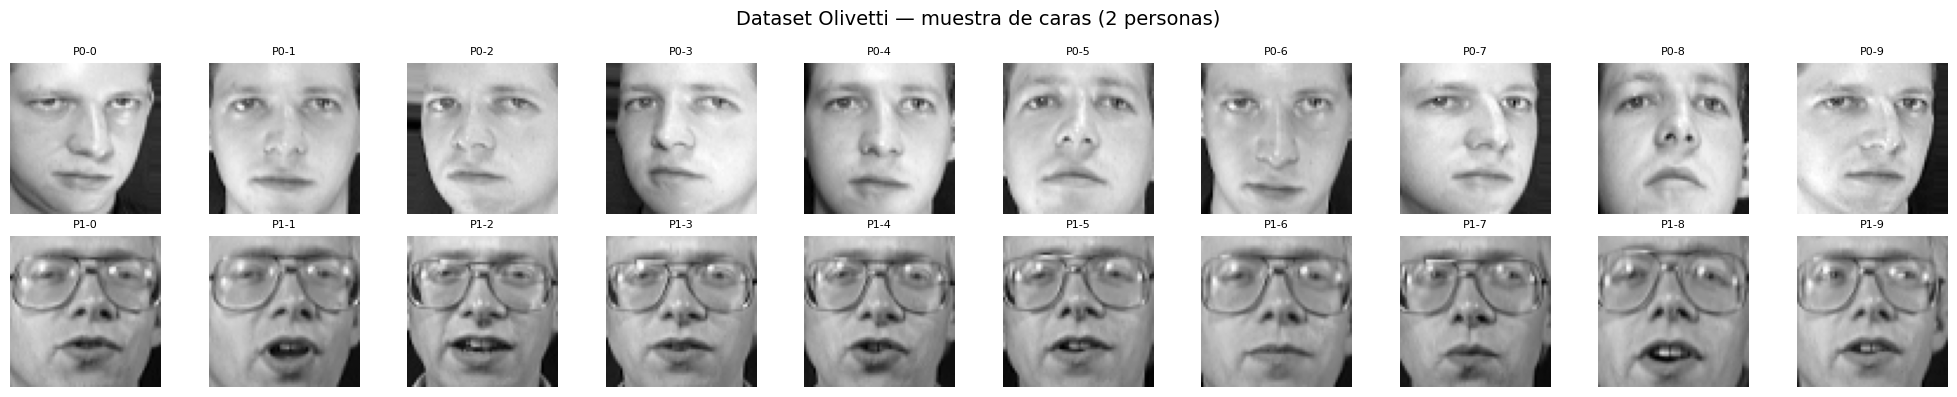

Rango de valores de píxeles: [0.000, 1.000]
Media: 0.547  |  Std: 0.173

 Los valores están normalizados en [0,1]. Dataset perfectamente balanceado (40 clases × 10 fotos).
No hay valores nulos. No necesitamos normalización adicional para el clasificador.


In [5]:
fig, axes = plt.subplots(2, 10, figsize=(20, 4))
fig.suptitle('Dataset Olivetti — muestra de caras (2 personas)', fontsize=14)

for i in range(10):
    #persona 0
    idx0 = np.where(y == 0)[0][i]
    axes[0, i].imshow(X[idx0].reshape(64, 64), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f'P0-{i}', fontsize=8)
    #persona 1
    idx1 = np.where(y == 1)[0][i]
    axes[1, i].imshow(X[idx1].reshape(64, 64), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title(f'P1-{i}', fontsize=8)

plt.tight_layout()
plt.show()

#Estadísticas básicas de píxeles
print(f"Rango de valores de píxeles: [{X.min():.3f}, {X.max():.3f}]")
print(f"Media: {X.mean():.3f}  |  Std: {X.std():.3f}")
print(f"\n Los valores están normalizados en [0,1]. Dataset perfectamente balanceado (40 clases × 10 fotos).")
print(f"No hay valores nulos. No necesitamos normalización adicional para el clasificador.")

#### 1.5 Modelo Base -  Random Forest con todas las Features

In [6]:
#RandomForest como clasificador base
baseline_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

#Cross-validation 5-fold con balanced_accuracy (= recall medio)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    baseline_clf, X_train, y_train,
    cv=cv,
    scoring='balanced_accuracy',
    n_jobs=-1
)

baseline_cv_score = cv_scores.mean()
print(f"CV scores (5-fold): {cv_scores.round(4)}")
print(f"CV balanced_accuracy media: {baseline_cv_score:.4f}")

#Entrenar en todo X_train y evaluar en test
baseline_clf.fit(X_train, y_train)
from sklearn.metrics import balanced_accuracy_score
y_pred = baseline_clf.predict(X_test)
baseline_test_score = balanced_accuracy_score(y_test, y_pred)

print(f"\nTest balanced_accuracy: {baseline_test_score:.4f}")
print(f"\n Guardamos CV={baseline_cv_score:.4f} y Test={baseline_test_score:.4f} como BASELINE")

CV scores (5-fold): [0.975  0.9    0.9375 0.925  0.9125]
CV balanced_accuracy media: 0.9300

Test balanced_accuracy: 0.9458

 Guardamos CV=0.9300 y Test=0.9458 como BASELINE


### #2 MODELO PARA LAS MICROCÁMARAS
**Objetivo:** Construir un modelo que pueda funcionar en las microcámaras, es decir que pueda funcionar con datos comprimidos.

Para cumplir con el objetivo se os ocurre emplear la doble propiedad de la PCA, que permite comprimir datos y mantener la capacidad informativa de estos. Sigue los siguientes pasos:
1. Instancia un objeto PCA sobre los datos de Train sin especificar ni componentes ni varianza explicada (o sea sin pasar argumentos).
2. Escoge un rango de valores para el número de PCAs que permitan por lo menos una compresión de la imagen de entre el 0.2% y el 2.5% (prueba al menos 5 valores). NOTA: La compresión es la reducción total, es decir una reducción del 1% quiere decir que el dataset se reduce a un 1% de su tamaño original)
3. Para el rango anterior entrena un modelo de clasificación y apunta su scoring en una validación cruzada de 5 folds y métrica el recall medio y su scoring contra test.
4. Muestra en un dataframe el valor de numero de componentes principales empleado, el scoring en CV, el scoring contra test, el % de compresión, la diferencia con el scoring de CV del modelo base, la diferencia con el scoring en test.
5. Escoge el número de componentes que permitirían tener la mayor compresión con una pérdida inferior a 3 puntos porcentuales tanto en CV como en test. Si no hay escoge el que tenga una pérdida inferior a 5 puntos porcentuales. 

#### 2.1 Instanciar PCA sin argumentos

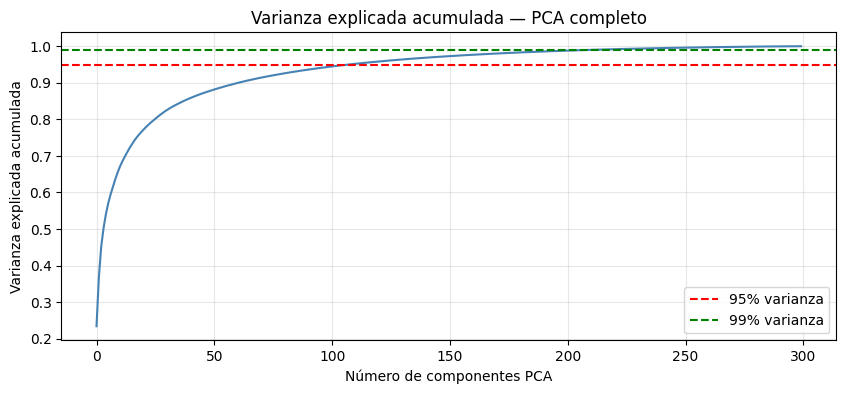

Componentes para 95% varianza: 109
Componentes para 99% varianza: 211


In [7]:
#PCA completo para ver la varianza explicada acumulada
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train)

#Varianza explicada acumulada
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 4))
plt.plot(cumvar, color='steelblue')
plt.xlabel('Número de componentes PCA')
plt.ylabel('Varianza explicada acumulada')
plt.title('Varianza explicada acumulada — PCA completo')
plt.axhline(0.95, color='red', linestyle='--', label='95% varianza')
plt.axhline(0.99, color='green', linestyle='--', label='99% varianza')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Componentes para 95% varianza: {np.argmax(cumvar >= 0.95) + 1}")
print(f"Componentes para 99% varianza: {np.argmax(cumvar >= 0.99) + 1}")

### 2.2 Rango de compresión 0.2% --> 2.5%

In [8]:
#n_features = 4096
#compresión = n_components / n_features
#0.2% de 4096 ≈ 8 componentes
#2.5% de 4096 ≈ 102 componentes

n_features = X_train.shape[1] 

#7 valores
n_components_list_p2 = [8, 15, 25, 40, 60, 82, 102]

print("Factores de compresión para #2:")
for nc in n_components_list_p2:
    pct = nc / n_features * 100
    print(f"  {nc:4d} componentes --> {pct:.2f}% del tamaño original")

Factores de compresión para #2:
     8 componentes --> 0.20% del tamaño original
    15 componentes --> 0.37% del tamaño original
    25 componentes --> 0.61% del tamaño original
    40 componentes --> 0.98% del tamaño original
    60 componentes --> 1.46% del tamaño original
    82 componentes --> 2.00% del tamaño original
   102 componentes --> 2.49% del tamaño original


#### 2.3 Entrenar y evaluar para cada número de componentes

In [9]:
from sklearn.metrics import balanced_accuracy_score

results_p2 = []

for nc in n_components_list_p2:
    #Pipeline: PCA + RandomForest
    pipe = Pipeline([
        ('pca', PCA(n_components=nc, random_state=RANDOM_STATE)),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
    ])
    
    #CV score
    cv_s = cross_val_score(pipe, X_train, y_train, cv=cv,
                            scoring='balanced_accuracy', n_jobs=-1).mean()
    
    #Test score
    pipe.fit(X_train, y_train)
    test_s = balanced_accuracy_score(y_test, pipe.predict(X_test))
    
    compression_pct = nc / n_features * 100
    
    results_p2.append({
        'n_componentes': nc,
        'compresion_%': round(compression_pct, 3),
        'CV_balanced_acc': round(cv_s, 4),
        'Test_balanced_acc': round(test_s, 4),
        'diff_CV_baseline': round(cv_s - baseline_cv_score, 4),
        'diff_Test_baseline': round(test_s - baseline_test_score, 4)
    })
    print(f"nc={nc:4d} | compresión={compression_pct:.2f}% | CV={cv_s:.4f} | Test={test_s:.4f}")

print("\nListo")

nc=   8 | compresión=0.20% | CV=0.7925 | Test=0.7875
nc=  15 | compresión=0.37% | CV=0.8600 | Test=0.8958
nc=  25 | compresión=0.61% | CV=0.9025 | Test=0.9375
nc=  40 | compresión=0.98% | CV=0.8900 | Test=0.9375
nc=  60 | compresión=1.46% | CV=0.9100 | Test=0.9292
nc=  82 | compresión=2.00% | CV=0.9125 | Test=0.9333
nc= 102 | compresión=2.49% | CV=0.9100 | Test=0.9333

Listo


#### 2.4 DataFrame de resultados

In [10]:
df_p2 = pd.DataFrame(results_p2)

#Resaltar fila óptima
def highlight_best(row):
    if row['diff_CV_baseline'] >= -0.03 and row['diff_Test_baseline'] >= -0.03:
        return ['background-color: lightgreen'] * len(row)
    return [''] * len(row)

print(f"BASELINE CV: {baseline_cv_score:.4f} | Test: {baseline_test_score:.4f}")
print()
df_p2.style.apply(highlight_best, axis=1)

BASELINE CV: 0.9300 | Test: 0.9458



,n_componentes,compresion_%,CV_balanced_acc,Test_balanced_acc,diff_CV_baseline,diff_Test_baseline
0,8,0.195000,0.792500,0.787500,-0.137500,-0.158300
1,15,0.366000,0.860000,0.895800,-0.070000,-0.050000
2,25,0.610000,0.902500,0.937500,-0.027500,-0.008300
3,40,0.977000,0.890000,0.937500,-0.040000,-0.008300
4,60,1.465000,0.910000,0.929200,-0.020000,-0.016700
5,82,2.002000,0.912500,0.933300,-0.017500,-0.012500
6,102,2.490000,0.910000,0.933300,-0.020000,-0.012500


#### 2.5 Selección del número óptimo de componentes

In [11]:
#Criterio: máxima compresión con pérdida < 3 puntos porcentuales (0.03) en CV Y test
candidatos = df_p2[
    (df_p2['diff_CV_baseline'] >= -0.03) &
    (df_p2['diff_Test_baseline'] >= -0.03)
]

if len(candidatos) > 0:
    #El que tiene menor % de compresión (mayor reducción de datos)
    elegido_p2 = candidatos.loc[candidatos['compresion_%'].idxmin()]
    print("Encontramos candidatos con pérdida < 3 puntos porcentuales:")
else:
    #Plan B: pérdida < 5 puntos
    candidatos = df_p2[
        (df_p2['diff_CV_baseline'] >= -0.05) &
        (df_p2['diff_Test_baseline'] >= -0.05)
    ]
    elegido_p2 = candidatos.loc[candidatos['compresion_%'].idxmin()]
    print("No hay candidatos con pérdida < 3pp. Usamos el umbral de 5pp:")

print(candidatos.to_string(index=False))
print(f"\nELECCIÓN para las microcámaras: {int(elegido_p2['n_componentes'])} componentes")
print(f"   Compresión: {elegido_p2['compresion_%']:.3f}% del tamaño original")
print(f"   CV score:   {elegido_p2['CV_balanced_acc']:.4f} (diff: {elegido_p2['diff_CV_baseline']:+.4f})")
print(f"   Test score: {elegido_p2['Test_balanced_acc']:.4f} (diff: {elegido_p2['diff_Test_baseline']:+.4f})")

best_nc_p2 = int(elegido_p2['n_componentes'])

Encontramos candidatos con pérdida < 3 puntos porcentuales:
 n_componentes  compresion_%  CV_balanced_acc  Test_balanced_acc  diff_CV_baseline  diff_Test_baseline
            25         0.610           0.9025             0.9375           -0.0275             -0.0083
            60         1.465           0.9100             0.9292           -0.0200             -0.0167
            82         2.002           0.9125             0.9333           -0.0175             -0.0125
           102         2.490           0.9100             0.9333           -0.0200             -0.0125

ELECCIÓN para las microcámaras: 25 componentes
   Compresión: 0.610% del tamaño original
   CV score:   0.9025 (diff: -0.0275)
   Test score: 0.9375 (diff: -0.0083)


### #3 COMPRESION PARA CLASIFICACION POSTERIOR

**Objetivo**: Obtener el número de componentes que permita una compresión menor y al tiempo que el modelo en el servidor central no baje su rendimiento respecto a no usar imágenes comprimidas.

Para esta parte la idea que se os ha ocurrido es emplear también la PCA como compresor ya que así siempre podrían pasar a la opción anterior si eso fuese suficiente. Pero en este caso no vamos a utilizar el dataset comprimido con las PCAs para detectar las caras, sino el dataset una vez descomprimido (recuerda que puede emplear `inverse_transform` para "descomprimir"). Los pasos a seguir son:

1. Escoge un rango de valores que  permitan una compresión aún mayor (recuerda que el ancho de banda es mínimo) entre el 1 por mil y el 1 por ciento. Escoge 5 valores de número de PCAs que permitan movernos en ese rango.
2. Para cada uno de esos valores: aplica la PCA al X_train, obten un X_train_unzipped aplicando la inversa de la PCA y entrena un modelo de clasificación y pruébalo contra test, apunta el balanced accuracy.
3. Crea un dataframe o haz un visualización comparando como es la medidad de balance accuracy para cada valor de número de pcas escogido y cuál su factor de compresión. 
4. Sabiendo que no podemos perder más de 3 puntos porcentuales respecto al baseline, ¿qué numero de PCA escogerías?

#### 3.1 Rango de componentes para compresión extrema

In [12]:
#0.1% --> ~4 componentes  |  1% --> ~41 componentes
n_components_list_p3 = [4, 8, 14, 25, 41]

print("Factores de compresión para #3:")
for nc in n_components_list_p3:
    pct = nc / n_features * 100
    print(f"  {nc:3d} componentes  {pct:.3f}% del tamaño original")

Factores de compresión para #3:
    4 componentes  0.098% del tamaño original
    8 componentes  0.195% del tamaño original
   14 componentes  0.342% del tamaño original
   25 componentes  0.610% del tamaño original
   41 componentes  1.001% del tamaño original


#### 3.2 Comprimir --> Descomprimir --> Clasificar

In [13]:
results_p3 = []

for nc in n_components_list_p3:
    #1) Comprimir con PCA
    pca = PCA(n_components=nc, random_state=RANDOM_STATE)
    X_train_compressed = pca.fit_transform(X_train)
    
    #2) Descomprimir con inverse_transform
    X_train_unzipped = pca.inverse_transform(X_train_compressed)
    X_test_compressed = pca.transform(X_test)
    X_test_unzipped = pca.inverse_transform(X_test_compressed)
    
    #3) Clasificar sobre los datos descomprimidos
    clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    clf.fit(X_train_unzipped, y_train)
    test_s = balanced_accuracy_score(y_test, clf.predict(X_test_unzipped))
    
    #También calcular varianza explicada retenida
    var_retenida = pca.explained_variance_ratio_.sum()
    compression_pct = nc / n_features * 100
    
    results_p3.append({
        'n_componentes': nc,
        'compresion_%': round(compression_pct, 3),
        'varianza_retenida_%': round(var_retenida * 100, 2),
        'Test_balanced_acc': round(test_s, 4),
        'diff_baseline': round(test_s - baseline_test_score, 4)
    })
    print(f"nc={nc:3d} | comp={compression_pct:.3f}% | var_ret={var_retenida*100:.1f}% | test={test_s:.4f} | diff={test_s-baseline_test_score:+.4f}")

print("\nListo")

nc=  4 | comp=0.098% | var_ret=50.3% | test=0.6375 | diff=-0.3083
nc=  8 | comp=0.195% | var_ret=61.6% | test=0.7750 | diff=-0.1708
nc= 14 | comp=0.342% | var_ret=71.0% | test=0.8083 | diff=-0.1375
nc= 25 | comp=0.610% | var_ret=79.7% | test=0.9458 | diff=+0.0000
nc= 41 | comp=1.001% | var_ret=85.9% | test=0.9625 | diff=+0.0167

Listo


#### 3.3 Comparativa visual

 n_componentes  compresion_%  varianza_retenida_%  Test_balanced_acc  diff_baseline
             4         0.098            50.290001             0.6375        -0.3083
             8         0.195            61.630001             0.7750        -0.1708
            14         0.342            70.989998             0.8083        -0.1375
            25         0.610            79.650002             0.9458         0.0000
            41         1.001            85.849998             0.9625         0.0167


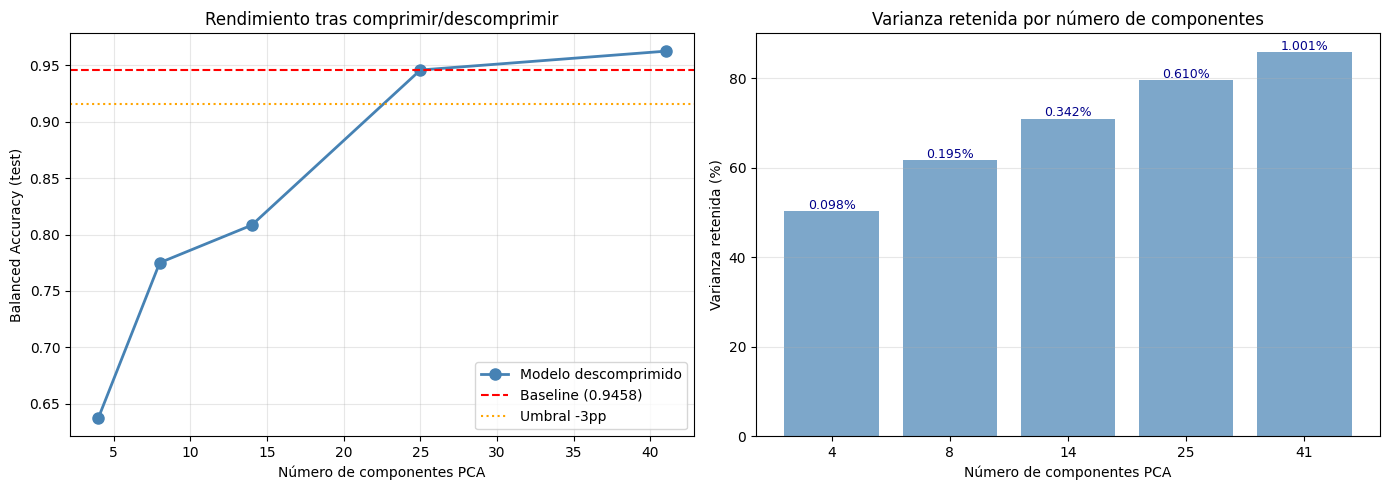

In [14]:
df_p3 = pd.DataFrame(results_p3)
print(df_p3.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Gráfico 1: Balanced Accuracy vs n_componentes
axes[0].plot(df_p3['n_componentes'], df_p3['Test_balanced_acc'],
             marker='o', color='steelblue', linewidth=2, markersize=8, label='Modelo descomprimido')
axes[0].axhline(baseline_test_score, color='red', linestyle='--', linewidth=1.5, label=f'Baseline ({baseline_test_score:.4f})')
axes[0].axhline(baseline_test_score - 0.03, color='orange', linestyle=':', linewidth=1.5, label='Umbral -3pp')
axes[0].set_xlabel('Número de componentes PCA')
axes[0].set_ylabel('Balanced Accuracy (test)')
axes[0].set_title('Rendimiento tras comprimir/descomprimir')
axes[0].legend()
axes[0].grid(alpha=0.3)

#Gráfico 2: Varianza retenida por número de componentes
bars = axes[1].bar(df_p3['n_componentes'].astype(str), df_p3['varianza_retenida_%'],
                   color='steelblue', alpha=0.7)
axes[1].set_xlabel('Número de componentes PCA')
axes[1].set_ylabel('Varianza retenida (%)')
axes[1].set_title('Varianza retenida por número de componentes')

#Etiquetas — usamos iloc para evitar el problema con nombres de columna especiales
for i, bar in enumerate(bars):
    comp_pct = df_p3['compresion_%'].iloc[i]
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{comp_pct:.3f}%", ha='center', fontsize=9, color='darkblue')

axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#### 3.4 Selección del número de componentes óptimo

In [15]:
#Criterio: máxima compresión con pérdida < 3 puntos porcentuales en test
candidatos_p3 = df_p3[df_p3['diff_baseline'] >= -0.03]

if len(candidatos_p3) > 0:
    elegido_p3 = candidatos_p3.loc[candidatos_p3['compresion_%'].idxmin()]
    print("Candidatos con pérdida < 3pp respecto al baseline:")
    print(candidatos_p3.to_string(index=False))
    print(f"\nELECCIÓN para el servidor central: {int(elegido_p3['n_componentes'])} componentes")
    print(f"   Compresión: {elegido_p3['compresion_%']:.3f}% del tamaño original")
    print(f"   Varianza retenida: {elegido_p3['varianza_retenida_%']:.1f}%")
    print(f"   Test balanced_accuracy: {elegido_p3['Test_balanced_acc']:.4f} (diff: {elegido_p3['diff_baseline']:+.4f})")
else:
    print("Ningún valor mantiene la pérdida bajo 3pp. Revisar rangos o cambiar umbral.")
    print(df_p3.to_string(index=False))

Candidatos con pérdida < 3pp respecto al baseline:
 n_componentes  compresion_%  varianza_retenida_%  Test_balanced_acc  diff_baseline
            25         0.610            79.650002             0.9458         0.0000
            41         1.001            85.849998             0.9625         0.0167

ELECCIÓN para el servidor central: 25 componentes
   Compresión: 0.610% del tamaño original
   Varianza retenida: 79.7%
   Test balanced_accuracy: 0.9458 (diff: +0.0000)


### #EXTRA

1. Para la segunda parte, visualiza en cuatro gráficos un scatter plot de las dos primeras componentes principales de la PCA escogida y colorea cada punto con las clases correspondientes a cada cara (como hay 40 clases, usa 10 por gráfico, 1-10 en el primero, 11-20 en el segundo, etc)
2. Para la tercer parte crea una función (modifica la de la práctica de la unidad de KMeans, por ejemplo) que permita ver la cara sin comprimir y la cara después de haberla descomprimido y haz una comprobación de cómo quedan (visualiza 5 caras por ejemplo) para cada uno de los valores de números de PCAs probados. Añade el caso para 150 y 320 PCs para que se vea que son las mismas claras con claridad.

## #EXTRA 1 — Scatter plot de las 2 primeras componentes PCA

Para la PCA elegida en la parte 2, visualizamos las 2 primeras componentes coloreadas por clase (10 clases por gráfico).

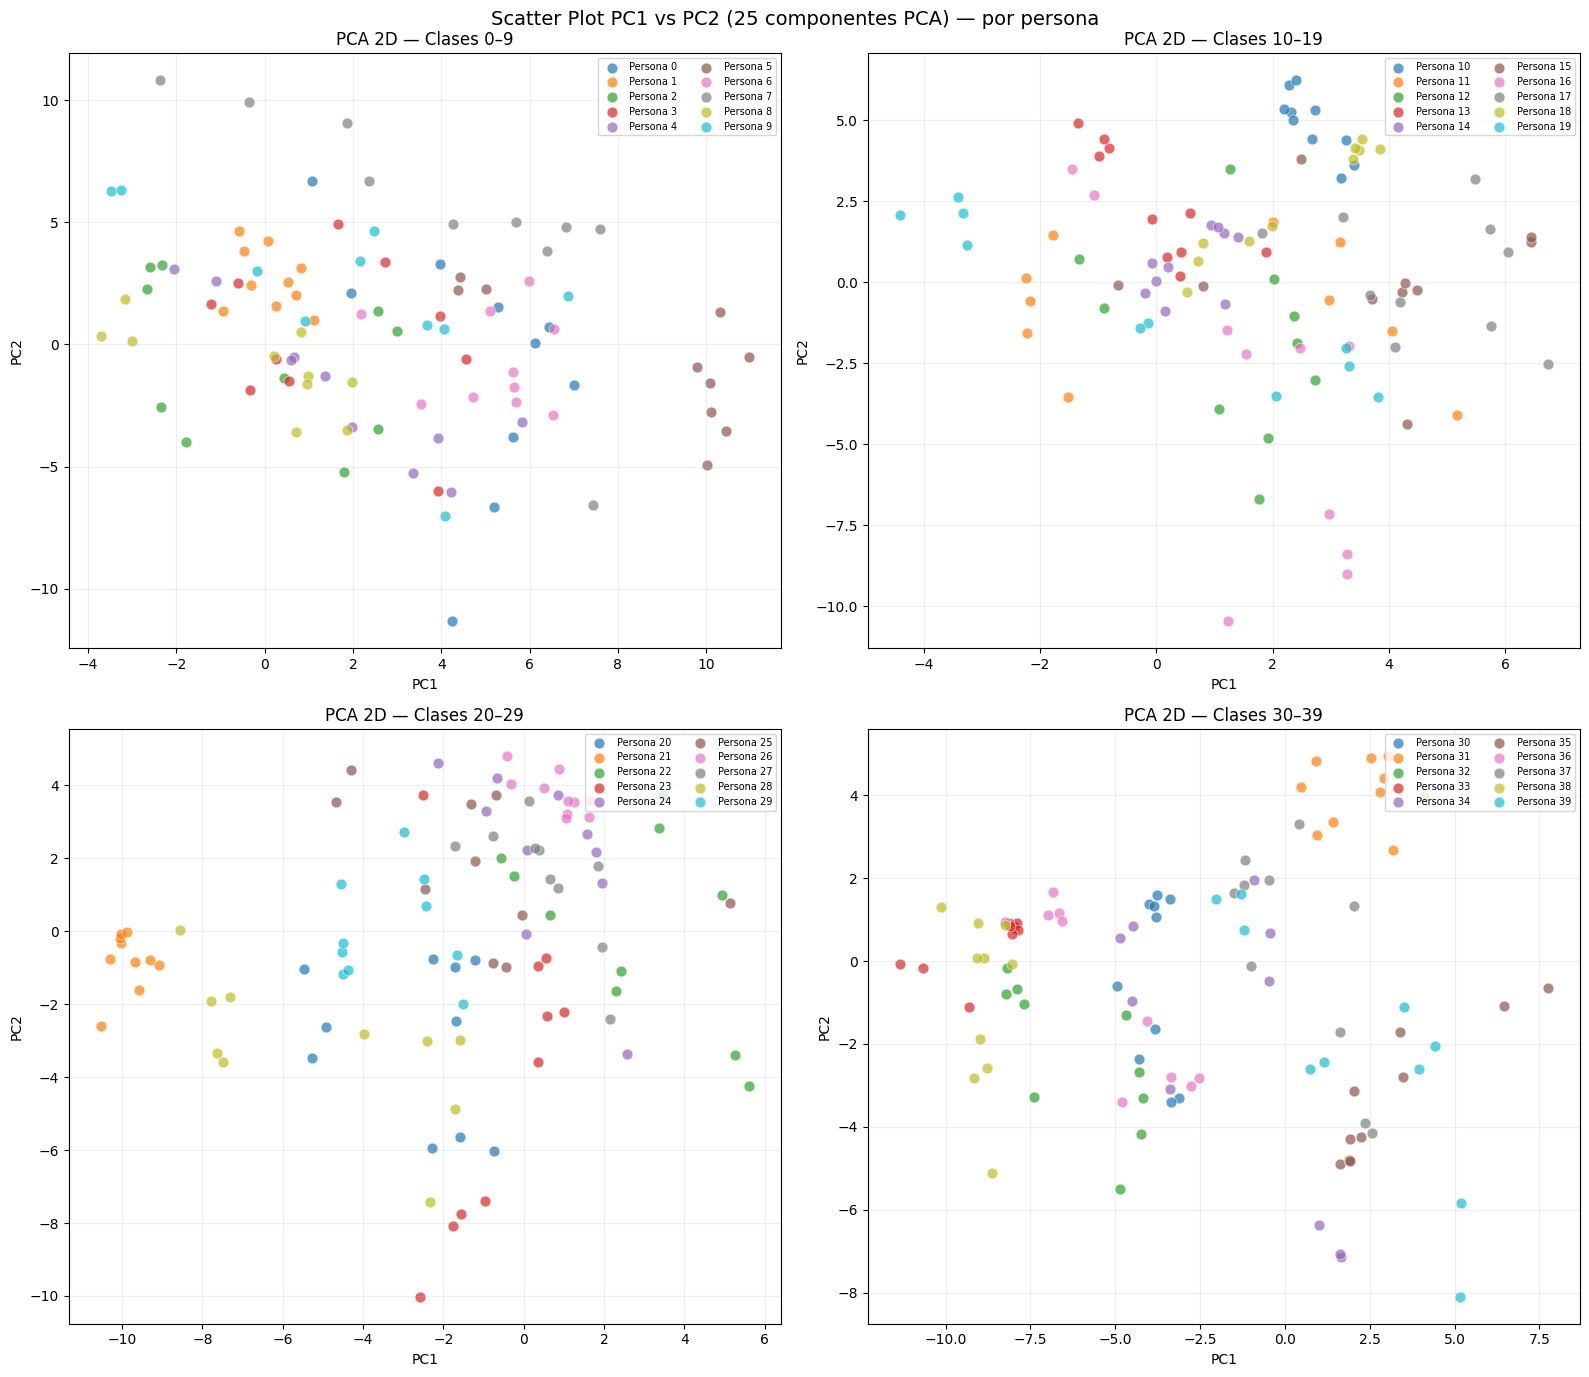

In [16]:
#Entrenamos la PCA elegida en #2
pca_extra = PCA(n_components=best_nc_p2, random_state=RANDOM_STATE)
X_pca_extra = pca_extra.fit_transform(X)  # usamos todo el dataset para visualizar

#40 clases --> 4 gráficos de 10 clases cada uno
class_groups = [(0,10), (10,20), (20,30), (30,40)]
paleta = sns.color_palette("tab10", 10)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (start, end) in enumerate(class_groups):
    ax = axes[idx]
    for i, clase in enumerate(range(start, end)):
        mask = y == clase
        ax.scatter(
            X_pca_extra[mask, 0],
            X_pca_extra[mask, 1],
            c=[paleta[i]],
            label=f'Persona {clase}',
            alpha=0.7,
            s=60,
            edgecolors='white',
            linewidth=0.5
        )
    ax.set_title(f'PCA 2D — Clases {start}–{end-1}', fontsize=12)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(loc='upper right', fontsize=7, ncol=2)
    ax.grid(alpha=0.2)

plt.suptitle(f'Scatter Plot PC1 vs PC2 ({best_nc_p2} componentes PCA) — por persona', fontsize=14)
plt.tight_layout()
plt.show()

## #EXTRA 2 — Visualización de caras comprimidas y descomprimidas

Función que muestra la cara original vs la reconstruida (tras comprimir y descomprimir con PCA).

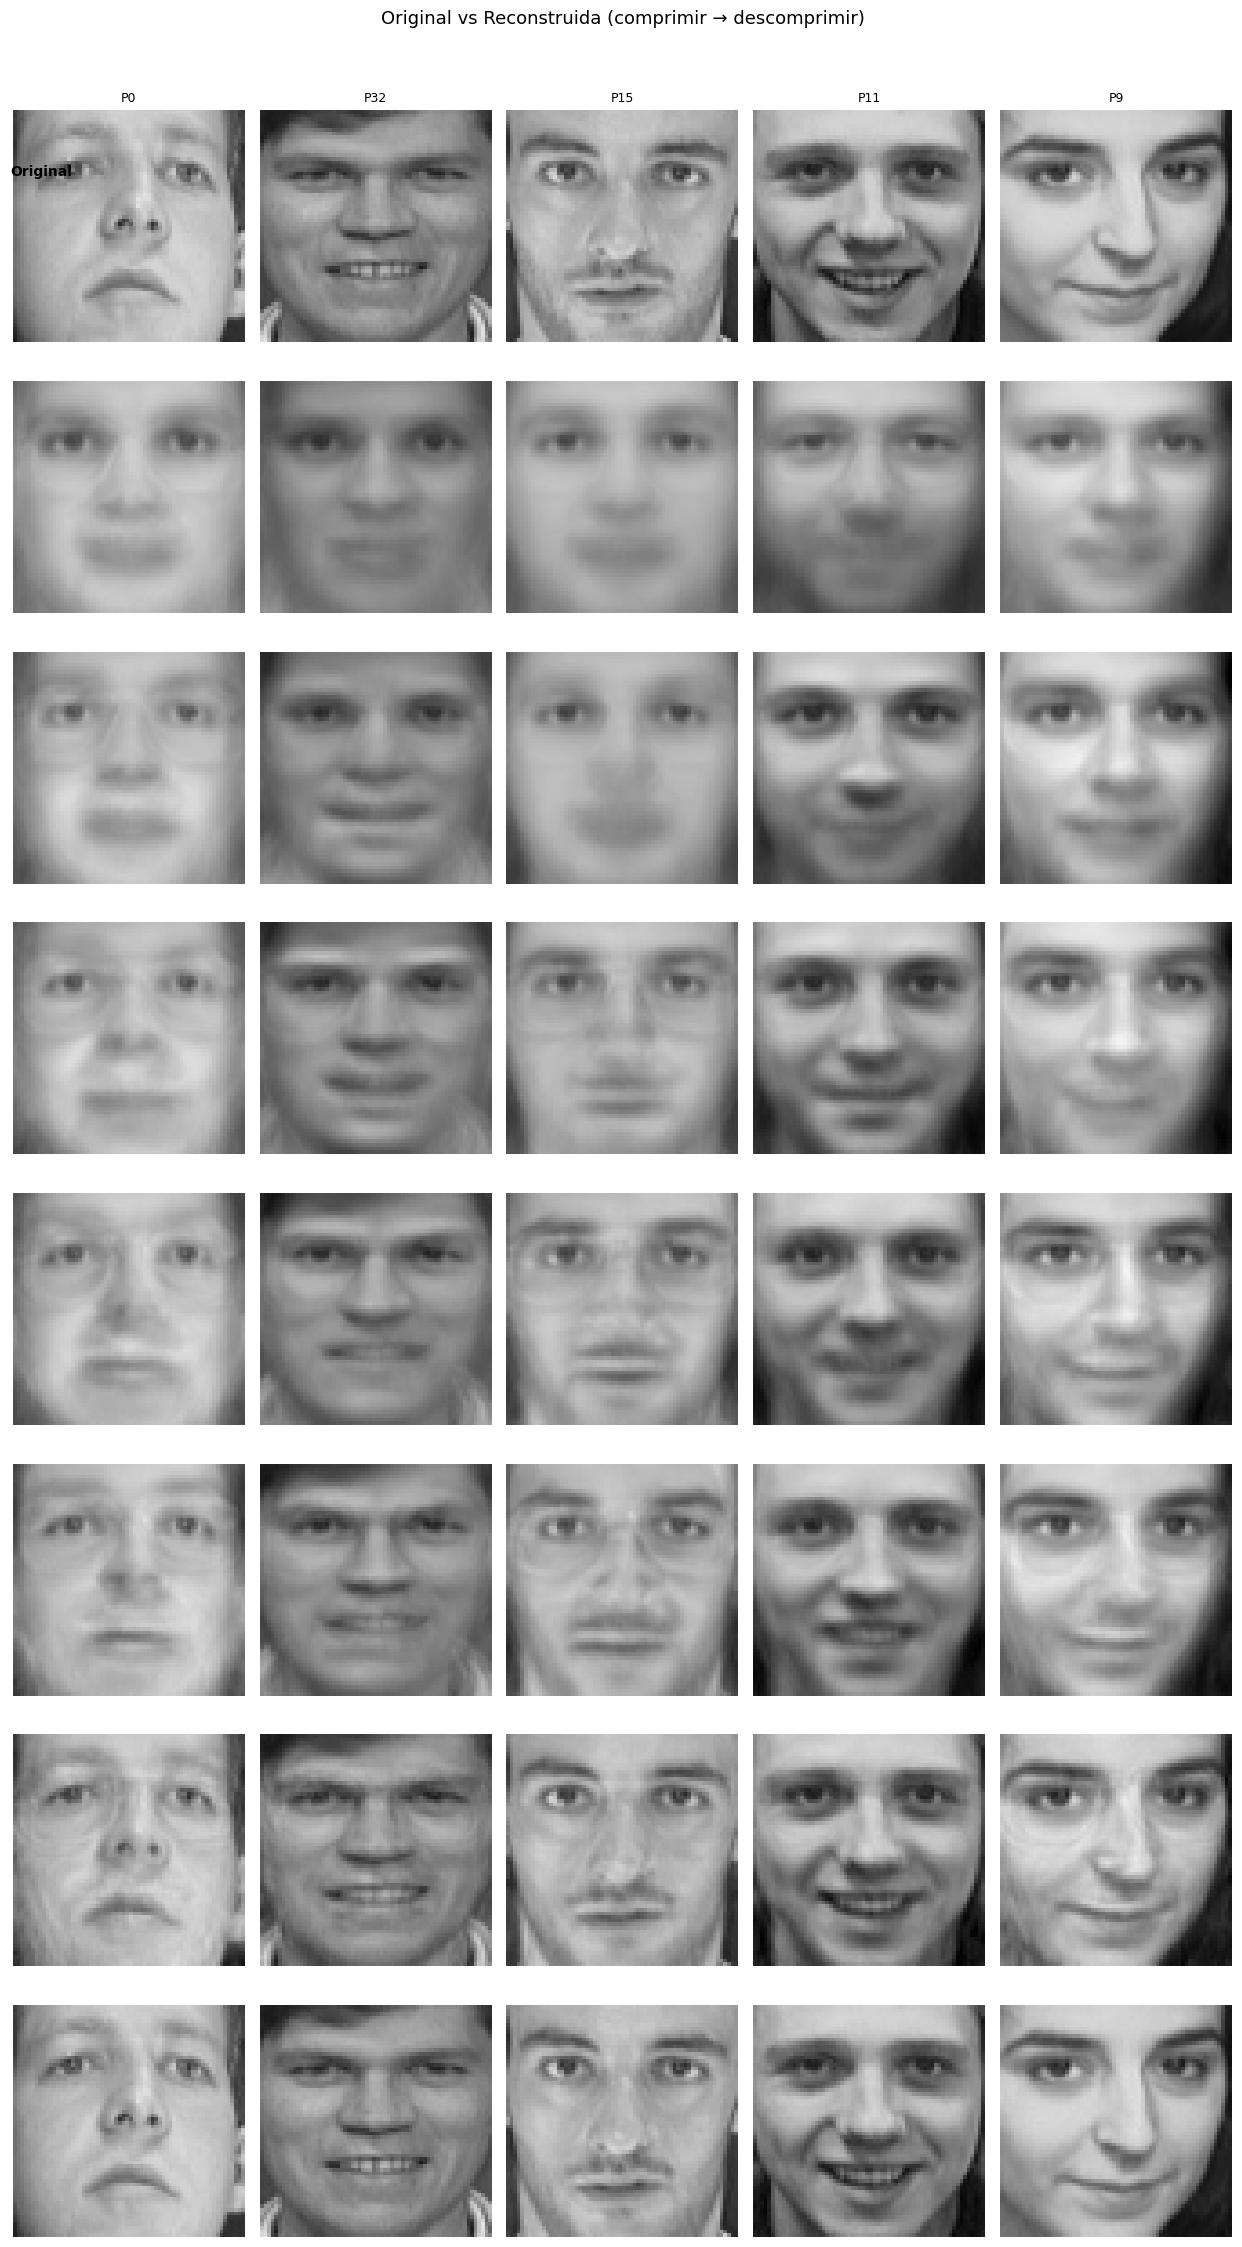

In [17]:
def plot_faces_original_vs_reconstructed(X, y, n_components_values, n_faces=5, random_state=42):
    """
    Muestra n_faces caras originales y su reconstrucción PCA
    para cada valor de n_components_values.
    
    Parámetros:
    -----------
    X : array-like (n_samples, n_features)
    y : array-like (n_samples,)
    n_components_values : list de int — valores de n_components a probar
    n_faces : int — número de caras a mostrar por fila
    """
    rng = np.random.default_rng(random_state)
    face_indices = rng.choice(len(X), size=n_faces, replace=False)
    
    #Filas: 1 original + 1 por cada n_components
    n_rows = 1 + len(n_components_values)
    fig, axes = plt.subplots(n_rows, n_faces, figsize=(n_faces * 2.5, n_rows * 2.8))
    
    #Fila 0: originales
    for col, idx in enumerate(face_indices):
        axes[0, col].imshow(X[idx].reshape(64, 64), cmap='gray', vmin=0, vmax=1)
        axes[0, col].set_title(f'P{y[idx]}', fontsize=9)
        axes[0, col].axis('off')
    axes[0, 0].set_ylabel('Original', fontsize=10)
    #Anotación de fila
    fig.text(0.01, 1 - 0.5/n_rows, 'Original', va='center', ha='left', fontsize=10, fontweight='bold')
    
    #Filas siguientes: reconstruidas
    for row_idx, nc in enumerate(n_components_values, start=1):
        pca_r = PCA(n_components=nc, random_state=random_state)
        X_compressed = pca_r.fit_transform(X)
        X_reconstructed = pca_r.inverse_transform(X_compressed)
        var = pca_r.explained_variance_ratio_.sum()
        comp_pct = nc / X.shape[1] * 100
        
        for col, idx in enumerate(face_indices):
            axes[row_idx, col].imshow(
                X_reconstructed[idx].reshape(64, 64),
                cmap='gray', vmin=0, vmax=1
            )
            axes[row_idx, col].axis('off')
        
        # Etiqueta de fila
        axes[row_idx, 0].set_ylabel(
            f'{nc} PCs\n({comp_pct:.2f}%)\nvar={var*100:.0f}%',
            fontsize=8
        )
    
    plt.suptitle('Original vs Reconstruida (comprimir → descomprimir)', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


#Valores de #3 + 150 y 320 para referencia visual
n_comp_extra = n_components_list_p3 + [150, 320]

plot_faces_original_vs_reconstructed(
    X, y,
    n_components_values=n_comp_extra,
    n_faces=5,
    random_state=RANDOM_STATE
)